In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
%matplotlib inline

In [2]:

#read dataset into pandas dataframe
loan_hist_df = pd.read_csv(r"C:\Users\s843971\Downloads\Loan_prediction_dataset.csv")

#split dataset into train and test 

train_loan_hist_df = loan_hist_df.iloc[0:614]

test_loan_hist_df = loan_hist_df.iloc[615:-1]




In [5]:

#display first 10 rows
train_loan_hist_df.head()
#print(head_loan_hist_df)

#to find out central tendencies and distribution of continuous variables
description_of_dataset = train_loan_hist_df.describe()

#to get total count of a selected column
value_counts_Property_Area = train_loan_hist_df['Property_Area'].value_counts()

#histogram_ApplicantIncome = loan_hist_df['ApplicantIncome'].hist(bins=50)

#boxplot_ApplicantIncome = loan_hist_df.boxplot(column='ApplicantIncome',by='Gender')

#checking how many missing values per column
train_loan_hist_df.apply(lambda x: sum(x.isnull()),axis = 0)

#imputing missing values with central tendencies
train_loan_hist_df['Gender'].fillna(train_loan_hist_df['Gender'].mode()[0], inplace=True)
train_loan_hist_df['Married'].fillna(train_loan_hist_df['Married'].mode()[0], inplace=True)
train_loan_hist_df['Dependents'].fillna(train_loan_hist_df['Dependents'].mode()[0], inplace=True)
train_loan_hist_df['Loan_Amount_Term'].fillna(train_loan_hist_df['Loan_Amount_Term'].mode()[0], inplace=True)
train_loan_hist_df['Credit_History'].fillna(train_loan_hist_df['Credit_History'].mode()[0], inplace=True)
train_loan_hist_df['Self_Employed'].fillna('No', inplace=True)
train_loan_hist_df['Credit_History'].fillna(train_loan_hist_df['Credit_History'].mode()[0], inplace=True)
train_loan_hist_df['LoanAmount'].fillna(train_loan_hist_df['LoanAmount'].median(), inplace=True)

#Tranforming features to get a normal distribution which will nullify the effects of outliers
train_loan_hist_df['LoanAmount_log'] = np.log(train_loan_hist_df['LoanAmount'])
train_loan_hist_df['TotalIncome'] = train_loan_hist_df['ApplicantIncome'] + train_loan_hist_df['CoapplicantIncome']
train_loan_hist_df['TotalIncome_log'] = np.log(train_loan_hist_df['TotalIncome'])



C:\Users\s843971\AppData\Local\Continuum\Anaconda3\lib\site-packages\pandas\core\generic.py:3549: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  self._update_inplace(new_data)
C:\Users\s843971\AppData\Local\Continuum\Anaconda3\lib\site-packages\ipykernel_launcher.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
C:\Users\s843971\AppData\Local\Continuum\Anaconda3\lib\site-packages\ipykernel_launcher.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://

In [6]:
#Predictive Modelling - fitting a model to the given dataset using sklearn

#As sklearn requires all inputs to be numeric, we should convert all our catagorical varibles into numeric by encoding catagories
from sklearn.preprocessing import LabelEncoder

var_mod = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Status']

le = LabelEncoder()

for i in var_mod:
    train_loan_hist_df[i] = le.fit_transform(train_loan_hist_df[i])
    




C:\Users\s843971\AppData\Local\Continuum\Anaconda3\lib\site-packages\ipykernel_launcher.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  # This is added back by InteractiveShellApp.init_path()


In [31]:
#Define a generic function for making a model and accessing performance

#from sklearn.cross_validation import KFold
from sklearn import metrics


def predictive_model(model,test_data,train_data,train_features,test_features,outcome):
    #fit the model
    model.fit(test_data[test_features],test_data[outcome])
    
    #make predictions on training set
    predictions = model.predict(test_features)
    print(predictions)
        
    #Calculate accuracy
    accuracy = metrics.accuracy_score(predictions,data[outcome])
    print("Accuracy: {}".format(accuracy))


In [32]:
#Using Logistic Regression model on the given dataset

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
predictor_var = ['Credit_History','Gender','Married','Self_Employed','TotalIncome_log','LoanAmount','Property_Area']
outcome_var = 'Loan_Status'


predictive_model(model,train_loan_hist_df,predictor_var,outcome_var)


[1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 1 0 1 1 1 0
 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1
 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1
 1 0 0 1 1 0 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 0 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 1 1
 1 1 1 1 1 0 1 1 1 1 1 1 

In [40]:
loan_hist_df['LoanAmount_log'] = np.log(loan_hist_df['LoanAmount'])
loan_hist_df['TotalIncome'] = loan_hist_df['ApplicantIncome'] + loan_hist_df['CoapplicantIncome']
loan_hist_df['TotalIncome_log'] = np.log(loan_hist_df['TotalIncome'])

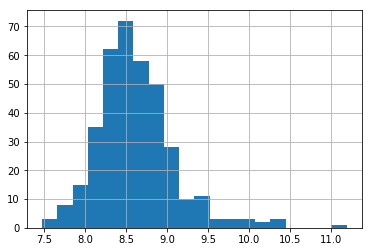

In [44]:
loan_hist_df['TotalIncome_log'].hist(bins=20)

In [17]:
loan_hist_df.apply(lambda x: sum(x.isnull()),axis = 0)

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
LoanAmount_log       0
TotalIncome          0
TotalIncome_log      0
dtype: int64

In [16]:
loan_hist_df[['Credit_History','LoanAmount']]

,Credit_History,LoanAmount
0,1.0,128.0
1,1.0,128.0
2,1.0,66.0
3,1.0,120.0
4,1.0,141.0
5,1.0,267.0
6,1.0,95.0
7,0.0,158.0
8,1.0,168.0
9,1.0,349.0


In [49]:
loan_hist_df.iloc[0:5,0:-1:2]

,Loan_ID,Married,Education,ApplicantIncome,LoanAmount,Credit_History,Loan_Status,TotalIncome
0,LP001002,0,0,5849,128.0,1.0,1,5849.0
1,LP001003,1,0,4583,128.0,1.0,0,6091.0
2,LP001005,1,0,3000,66.0,1.0,1,3000.0
3,LP001006,1,1,2583,120.0,1.0,1,4941.0
4,LP001008,0,0,6000,141.0,1.0,1,6000.0


In [4]:
df['Property_Area'].value_counts()

Urban        140
Semiurban    116
Rural        111
Name: Property_Area, dtype: int64

In [9]:
df['Education'].value_counts()

pandas.core.series.Series

In [21]:
df.pivot_table(values=['LoanAmount','ApplicantIncome'],columns=['Self_Employed'], index=['Property_Area'],aggfunc=np.mean)

ApplicantIncome               LoanAmount            
Self_Employed              No          Yes          No         Yes
Property_Area                                                     
Rural             4459.435294  5659.611111  136.416667  149.055556
Semiurban         4413.059406  7934.375000  130.747475  186.625000
Urban             4944.000000  4729.272727  134.294118  125.545455

In [20]:
df.pivot_table(values=['LoanAmount','ApplicantIncome'], index=['Property_Area','Self_Employed'],aggfunc=np.mean)

ApplicantIncome  LoanAmount
Property_Area Self_Employed                             
Rural         No                 4459.435294  136.416667
              Yes                5659.611111  149.055556
Semiurban     No                 4413.059406  130.747475
              Yes                7934.375000  186.625000
Urban         No                 4944.000000  134.294118
              Yes                4729.272727  125.545455

In [25]:
table = df.pivot_table(values='LoanAmount', index='Self_Employed' ,columns='Education', aggfunc=np.median)

In [28]:
table.loc[x['Self_Employed'],x['Education']]

NameError: name 'x' is not defined

In [40]:
def missing_vals(x):
    return sum(x.isnull())



In [42]:
df.apply(missing_vals, axis = 0)

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [4]:
x = map(tuple,df.values)

In [5]:
print(x)

In [6]:
next(x)

('LP001015',
 'Male',
 'Yes',
 '0',
 'Graduate',
 'No',
 5720,
 0,
 110.0,
 360.0,
 1.0,
 'Urban')

In [8]:
for y in x:
    print(y)

('LP001022', 'Male', 'Yes', '1', 'Graduate', 'No', 3076, 1500, 126.0, 360.0, 1.0, 'Urban')
('LP001031', 'Male', 'Yes', '2', 'Graduate', 'No', 5000, 1800, 208.0, 360.0, 1.0, 'Urban')
('LP001035', 'Male', 'Yes', '2', 'Graduate', 'No', 2340, 2546, 100.0, 360.0, nan, 'Urban')
('LP001051', 'Male', 'No', '0', 'Not Graduate', 'No', 3276, 0, 78.0, 360.0, 1.0, 'Urban')
('LP001054', 'Male', 'Yes', '0', 'Not Graduate', 'Yes', 2165, 3422, 152.0, 360.0, 1.0, 'Urban')
('LP001055', 'Female', 'No', '1', 'Not Graduate', 'No', 2226, 0, 59.0, 360.0, 1.0, 'Semiurban')
('LP001056', 'Male', 'Yes', '2', 'Not Graduate', 'No', 3881, 0, 147.0, 360.0, 0.0, 'Rural')
('LP001059', 'Male', 'Yes', '2', 'Graduate', nan, 13633, 0, 280.0, 240.0, 1.0, 'Urban')
('LP001067', 'Male', 'No', '0', 'Not Graduate', 'No', 2400, 2400, 123.0, 360.0, 1.0, 'Semiurban')
('LP001078', 'Male', 'No', '0', 'Not Graduate', 'No', 3091, 0, 90.0, 360.0, 1.0, 'Urban')
('LP001082', 'Male', 'Yes', '1', 'Graduate', nan, 2185, 1516, 162.0, 360.0, 1

('LP002016', 'Male', 'Yes', '2', 'Graduate', 'No', 5128, 0, 143.0, 360.0, 1.0, 'Rural')
('LP002017', 'Male', 'Yes', '3+', 'Graduate', 'No', 15312, 0, 187.0, 360.0, nan, 'Urban')
('LP002018', 'Male', 'Yes', '2', 'Graduate', 'No', 3958, 2632, 160.0, 360.0, 1.0, 'Semiurban')
('LP002027', 'Male', 'Yes', '0', 'Graduate', 'No', 4334, 2945, 165.0, 360.0, 1.0, 'Semiurban')
('LP002028', 'Male', 'Yes', '2', 'Graduate', 'No', 4358, 0, 110.0, 360.0, 1.0, 'Urban')
('LP002042', 'Female', 'Yes', '1', 'Graduate', 'No', 4000, 3917, 173.0, 360.0, 1.0, 'Rural')
('LP002045', 'Male', 'Yes', '3+', 'Graduate', 'No', 10166, 750, 150.0, nan, 1.0, 'Urban')
('LP002046', 'Male', 'Yes', '0', 'Not Graduate', 'No', 4483, 0, 135.0, 360.0, nan, 'Semiurban')
('LP002047', 'Male', 'Yes', '2', 'Not Graduate', 'No', 4521, 1184, 150.0, 360.0, 1.0, 'Semiurban')
('LP002056', 'Male', 'Yes', '2', 'Graduate', 'No', 9167, 0, 235.0, 360.0, 1.0, 'Semiurban')
('LP002057', 'Male', 'Yes', '0', 'Not Graduate', 'No', 13083, 0, nan, 360.

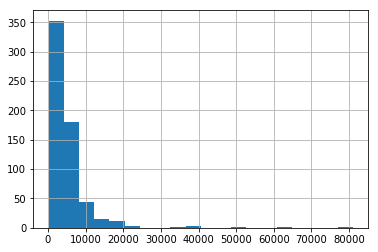

In [9]:
train_loan_hist_df['ApplicantIncome'].hist(bins=20)

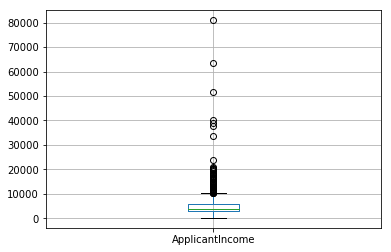

In [10]:
train_loan_hist_df.boxplot(column = 'ApplicantIncome')

In [4]:
train_loan_hist_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000
